## Loading and exploring the article data

In [9]:
## data is stored in a jsonl file, one json object per line
import pandas as pd
import json
import os

# Load the data, using parquet if available, otherwise load JSONL and save as parquet
if os.path.exists('../data/processed/cfgen_articles.parquet'):
    articles = pd.read_parquet('../data/processed/cfgen_articles.parquet')
else:
    articles = pd.read_json('../data/raw/cfgen_articles.jsonl', lines=True)
    # sanitize for parquet
    import json
    # Convert any dictionary/object columns to strings to avoid Arrow type errors, by checking if the column is a dictionary
    for col in articles.select_dtypes(include=['object']).columns:
        articles[col] = articles[col].apply(lambda x: json.dumps(x) if isinstance(x, dict) else x)
    articles.to_parquet('../data/processed/cfgen_articles.parquet')

In [10]:
# Count articles with publishing dates
articles_with_dates = articles.dropna(subset=['publishing_date'])
print(f"Number of articles with publishing dates: {len(articles_with_dates)}")
print(f"Percentage of articles with publishing dates: {(len(articles_with_dates) / len(articles)) * 100:.2f}%")

Number of articles with publishing dates: 443409
Percentage of articles with publishing dates: 100.00%


In [11]:
# convert to datetime
articles.publishing_date = pd.to_datetime(articles.publishing_date, format='mixed', utc=True)

In [12]:
articles.publishing_date = articles.publishing_date.dt.tz_localize(None)

In [13]:
# filter out articles with publishing date before 2025
articles = articles[articles.publishing_date >= pd.Timestamp('2025-01-01')]


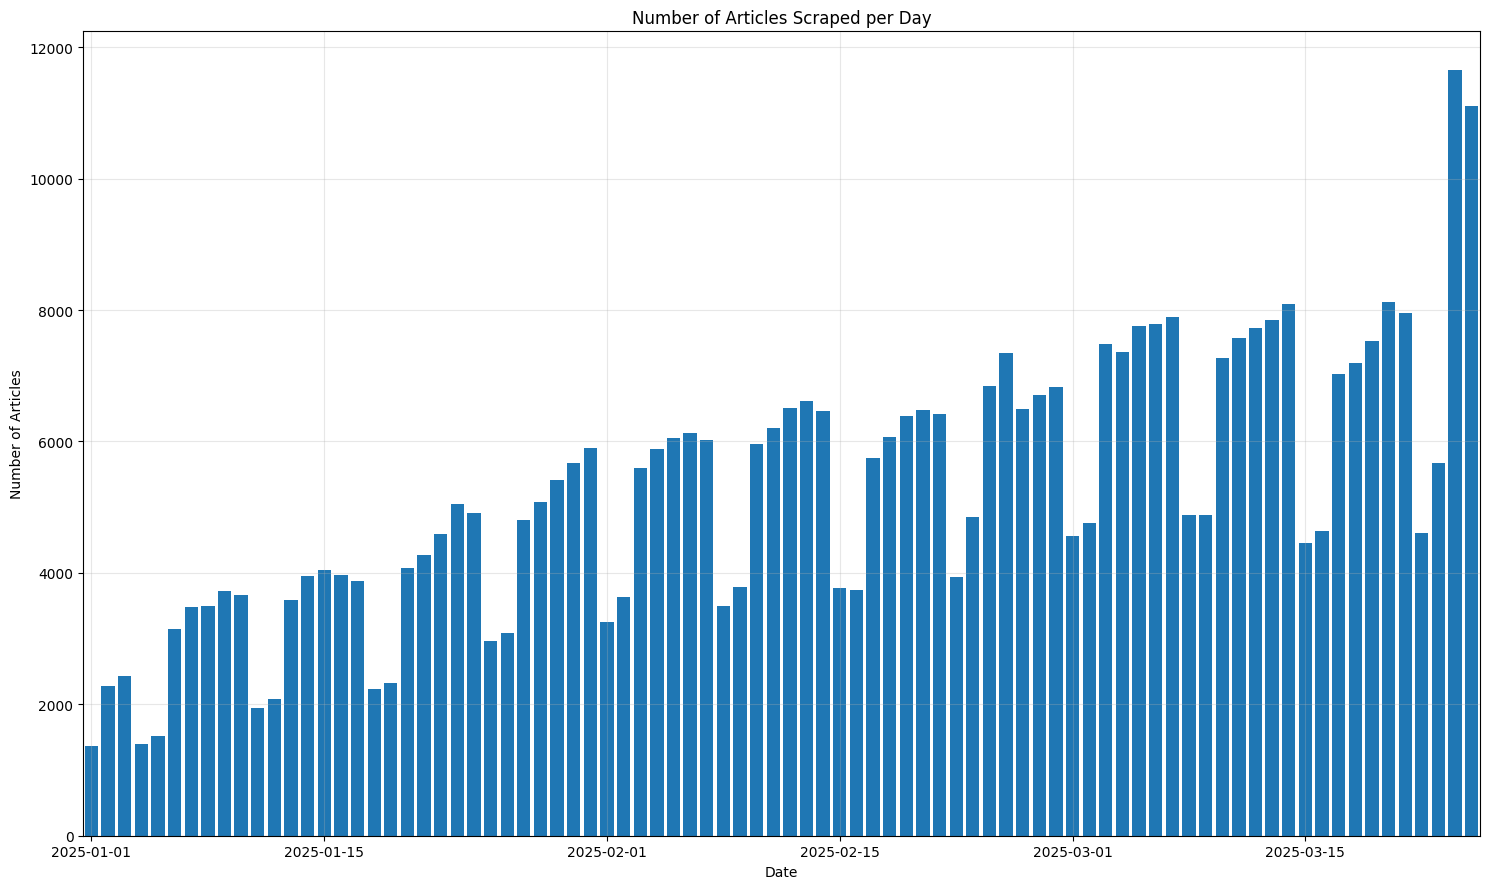

In [14]:
# plot distribution of articles per day
import matplotlib.pyplot as plt

# Count articles per day
articles_per_day = articles.groupby(articles.publishing_date.dt.date).size()

# Create a line plot
from datetime import datetime, date


plt.figure(figsize=(15, 9))
plt.bar(articles_per_day.index, articles_per_day.values, width=.8)
plt.title('Number of Articles Scraped per Day')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.xlim(pd.Timestamp('2025-01-01')-pd.Timedelta(hours=12), pd.Timestamp('2025-03-26')-pd.Timedelta(hours=12))
plt.tight_layout()
plt.show()

In [ ]:
## get rid of articles without text
articles = articles.dropna(subset=['plaintext'])

# filter articles with plaintext length less than 100
articles = articles[articles.plaintext.str.len() > 100]

## detect language of each article, batched
from lingua import Language, LanguageDetectorBuilder
from tqdm.notebook import tqdm

# Build detector with all languages
detector = LanguageDetectorBuilder.from_all_languages().build()

def detect_language_batch(texts, batch_size=10000):
    languages = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        batch_langs = detector.detect_languages_in_parallel_of(batch)
        for lang in batch_langs:
            languages.append(lang.name.lower() if lang else 'unknown')
    return languages

# Detect languages
articles['language'] = detect_language_batch(articles.plaintext.values)

# Print language distribution
print("\nLanguage distribution:")
print(articles.language.value_counts())

# save back to pqt
articles.to_parquet("../data/processed/cfgen_articles.parquet")

  0%|          | 0/45 [00:00<?, ?it/s]

KeyboardInterrupt: 

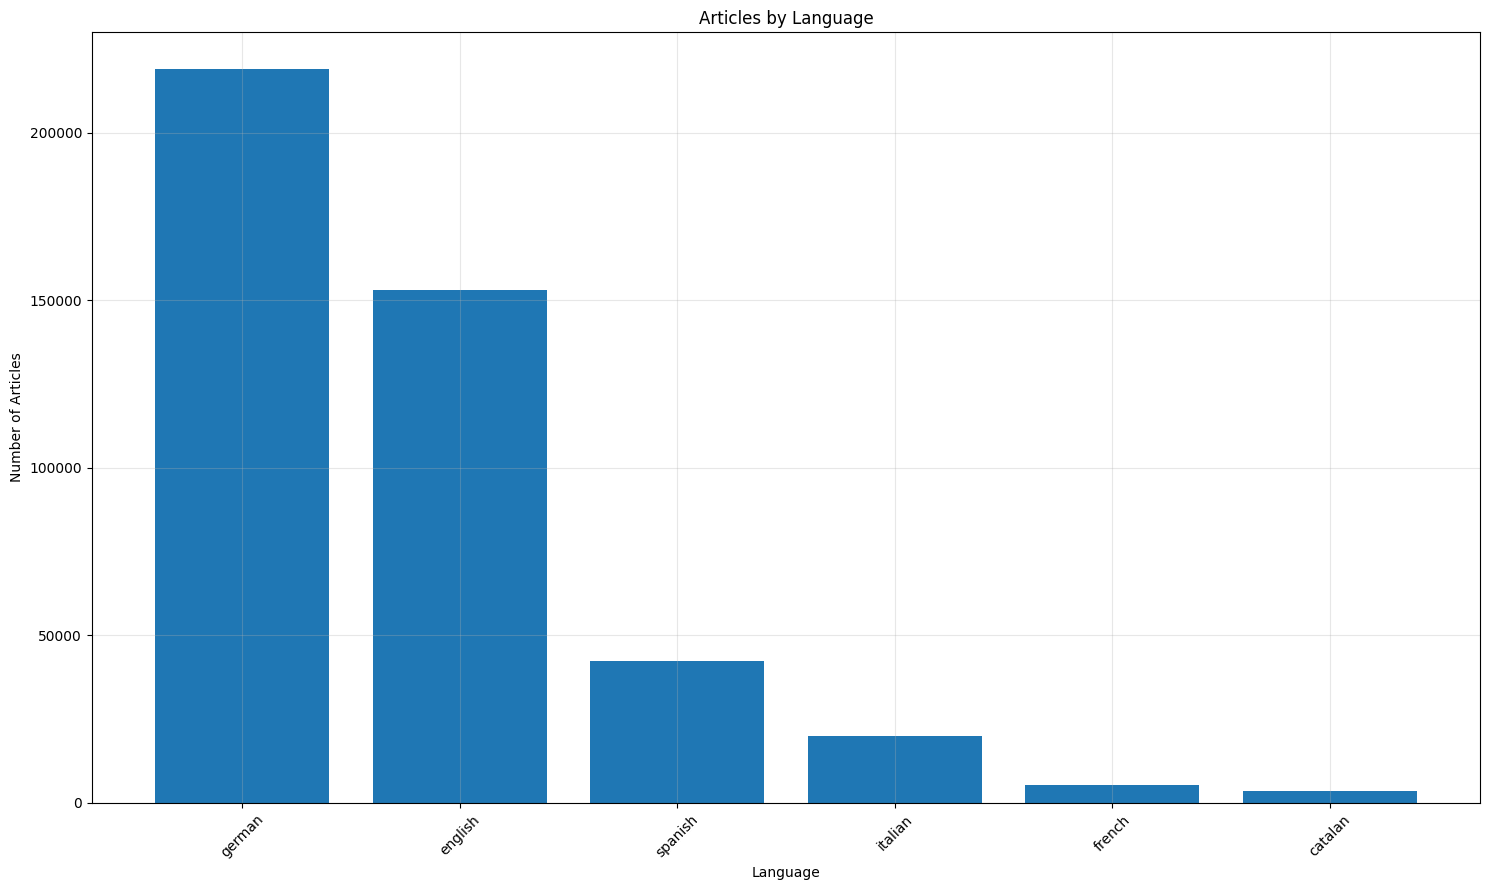

language
german     219092
english    153020
spanish     42468
italian     19873
french       5329
catalan      3627
Name: count, dtype: int64


In [34]:
## plot by language
# exclude languages with less than 100 articles
articles = articles[articles.language != 'unknown']
good_langs = articles.language.value_counts()[articles.language.value_counts() > 1000].index
articles = articles[articles.language.isin(good_langs)]

# Group by language and plot
lang_totals = articles.groupby('language').size().sort_values(ascending=False)

plt.figure(figsize=(15, 9))
plt.bar(range(len(lang_totals)), lang_totals.values, width=0.8)
plt.title('Articles by Language')
plt.xlabel('Language')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.xticks(range(len(lang_totals)), lang_totals.index, rotation=45)
plt.tight_layout()
plt.show()

print(articles.language.value_counts())

In [35]:
# let's see how many are french
french_articles = articles[articles.language == 'french']
print(f"Number of french articles: {len(french_articles)}")
print(f"Percentage of french articles: {(len(french_articles) / len(articles)) * 100:.2f}%")

# let's see how many are english
english_articles = articles[articles.language == 'english']


Number of french articles: 5329
Percentage of french articles: 1.20%


In [36]:

# create a mapping of sources to their primary languages/nations
source_to_nation = {
    # German sources
    'Münchner Merkur': 'de', 'Rheinische Post': 'de', 'Bild': 'de', 'Die Welt': 'de',
    'Die Zeit': 'de', 'Tagesspiegel': 'de', 'N-Tv': 'de', 'Norddeutscher Rundfunk (NDR)': 'de',
    'Frankfurter Rundschau': 'de', 'Berliner Morgenpost': 'de', 'Hamburger Abendblatt': 'de',
    'Business Insider DE': 'de', 'Sportschau': 'de', 'Bayerischer Rundfunk (BR)': 'de',
    'Golem': 'de', 'Frankfurter Allgemeine Zeitung': 'de', 'Euronews (DE)': 'de',
    'Die Tageszeitung (taz)': 'de', 'Deutsche Welle': 'de', 'Mitteldeutsche Zeitung': 'de',
    'Westdeutsche Allgemeine Zeitung (WAZ)': 'de', 'Braunschweiger Zeitung': 'de',
    'Postillon': 'de', 'Mitteldeutscher Rundfunk (MDR)': 'de', 'Ruhr Nachrichten': 'de',
    'Spiegel Online': 'de', 'Kicker': 'de', 'netzpolitik.org': 'de', 'Börsen-Zeitung': 'de',
    'ZDF': 'de', 'WinFuture': 'de', 'Krautreporter': 'de', 'Gamestar': 'de',
    'Tagesschau': 'de', 'Westdeutscher Rundfunk': 'de', 'Focus Online': 'de',
    'Junge Welt': 'de', 'Süddeutsche Zeitung': 'de', 'Stern': 'de', 'FreiePresse': 'de',
    'Heise': 'de', 'Hessenschau': 'de',

    # UK sources
    'The Independent': 'uk', 'The BBC': 'uk', 'The Sun': 'uk', 'Evening Standard': 'uk',
    'Daily Express': 'uk', 'Metro': 'uk', 'Daily Star': 'uk', 'i': 'uk',
    'The Mirror': 'uk', 'Daily Mail': 'uk', 'The Guardian': 'uk',

    # US sources
    'Associated Press News': 'us', 'The Washington Times': 'us', 'Voice Of America': 'us',
    'CNBC': 'us', 'Rolling Stone': 'us', 'The Gateway Pundit': 'us', 'ABC': 'us',
    'The New Yorker': 'us', 'Wired': 'us', 'The Washington Free Beacon': 'us',
    'Vogue': 'us', 'The Nation': 'us', 'Fox News': 'us', 'The Intercept': 'us',
    'Business Insider': 'us', 'Los Angeles Times': 'us', 'TechCrunch': 'us',

    # Spanish sources
    'La Vanguardia': 'es', 'El País': 'es', 'El Mundo': 'es',

    # Italian sources  
    'La Repubblica': 'it', 'Il Giornale': 'it', 'Corriere della Sera': 'it',

    # French sources
    'Le Figaro': 'fr', 'Euronews (FR)': 'fr', 'Le Monde': 'fr',

    # International/Multiple languages
    'Euronews (EN)': 'int', 'MotorSport Magazin': 'int'
}

# map the nations to the articles based on their source
articles['country'] = articles['source'].map(source_to_nation)

# save once again
articles.to_parquet("cfgen_articles.parquet")

: 